Objective: The main goal of this assignment is to conduct a thorough exploratory analysis of the "cardiographic.csv" dataset to uncover insights, identify patterns, and understand the dataset's underlying structure. You will use statistical summaries, visualizations, and data manipulation techniques to explore the dataset comprehensively.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/Cardiotocographic (1).csv")

df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


2. Data Cleaning & Preparation

In [6]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


,0
LB,21
AC,20
FM,0
UC,0
DL,0
DS,21
DP,21
ASTV,0
MSTV,0
ALTV,0


In [7]:
df = df.fillna(df.mean(numeric_only=True))

In [8]:
df.dtypes

,0
LB,float64
AC,float64
FM,float64
UC,float64
DL,float64
DS,float64
DP,float64
ASTV,float64
MSTV,float64
ALTV,float64


In [9]:
Q1 = df['LB'].quantile(0.25)
Q3 = df['LB'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['LB'] >= Q1 - 1.5*IQR) & (df['LB'] <= Q3 + 1.5*IQR)]

3. Statistical Summary

In [10]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000
mean,133.268648,0.003216,0.009927,0.004385,0.001899,0.000003,0.000176,47.049159,1.364731,10.322760,8.275317,70.399908,0.315504,1.305478
std,9.766438,0.004375,0.067697,0.003299,0.003347,0.000141,0.000837,18.680790,1.175361,21.245105,7.742562,42.748306,0.642898,0.642453
min,106.000000,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001858,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001668,0.000000,0.004496,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.500000,68.000000,0.000000,1.000000
75%,140.000000,0.005598,0.002568,0.006540,0.003304,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.000067
max,160.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


In [11]:
summary = df.describe().T
summary['median'] = df.median()
summary['IQR'] = df.quantile(0.75) - df.quantile(0.25)
summary

,count,mean,std,min,25%,50%,75%,max,median,IQR
LB,2116.0,133.268648,9.766438,106.000000,126.000000,133.000000,140.000000,160.000000,133.000000,14.000000
AC,2116.0,0.003216,0.004375,-0.019284,0.000000,0.001668,0.005598,0.038567,0.001668,0.005598
FM,2116.0,0.009927,0.067697,-0.480634,0.000000,0.000000,0.002568,0.961268,0.000000,0.002568
UC,2116.0,0.004385,0.003299,-0.014925,0.001858,0.004496,0.006540,0.030002,0.004496,0.004681
DL,2116.0,0.001899,0.003347,-0.015393,0.000000,0.000000,0.003304,0.030769,0.000000,0.003304
DS,2116.0,0.000003,0.000141,-0.001353,0.000000,0.000000,0.000000,0.002706,0.000000,0.000000
DP,2116.0,0.000176,0.000837,-0.005348,0.000000,0.000000,0.000000,0.010695,0.000000,0.000000
ASTV,2116.0,47.049159,18.680790,-63.000000,32.000000,49.000000,61.000000,162.000000,49.000000,29.000000
MSTV,2116.0,1.364731,1.175361,-6.600000,0.700000,1.200000,1.700000,13.800000,1.200000,1.000000
ALTV,2116.0,10.322760,21.245105,-91.000000,0.000000,0.000000,11.000000,182.000000,0.000000,11.000000


4. Data Visualization

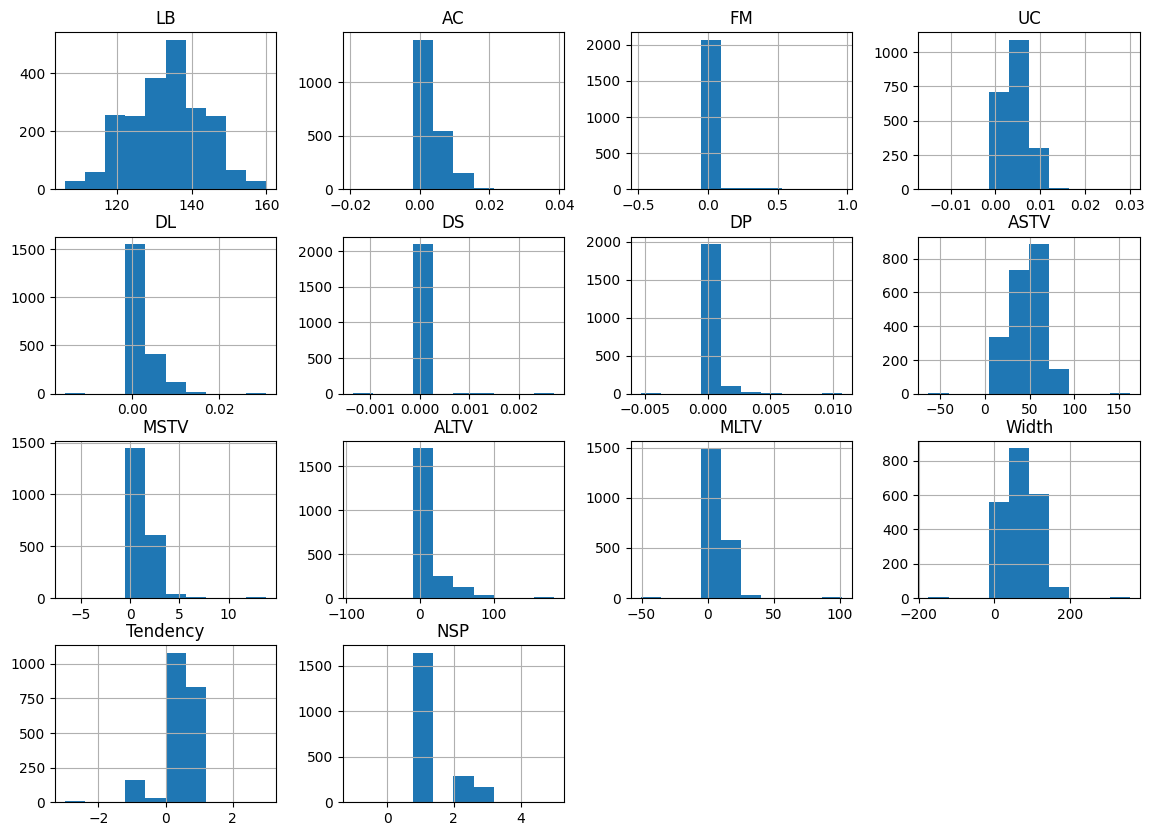

In [12]:
#Histograms
df.hist(figsize=(14,10))
plt.show()

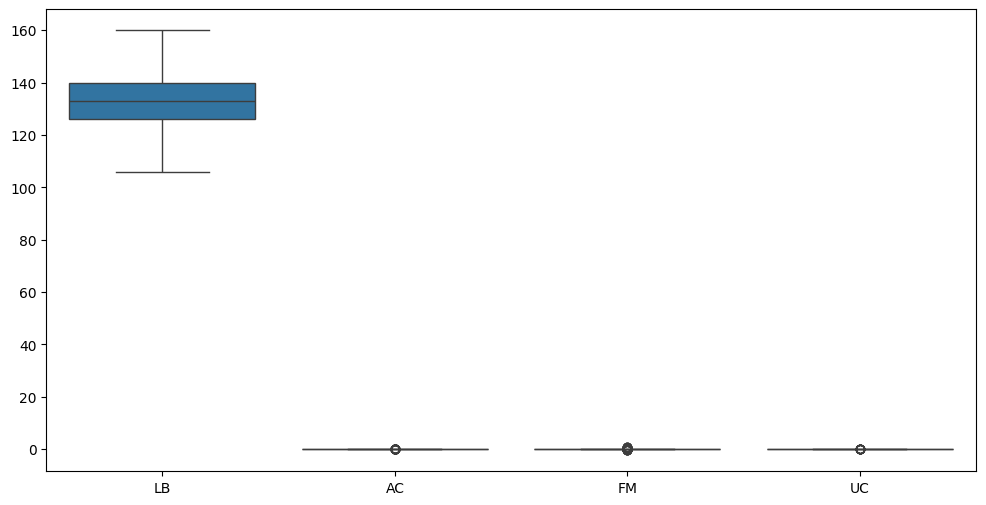

In [13]:
#Boxplots
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['LB','AC','FM','UC']])
plt.show()

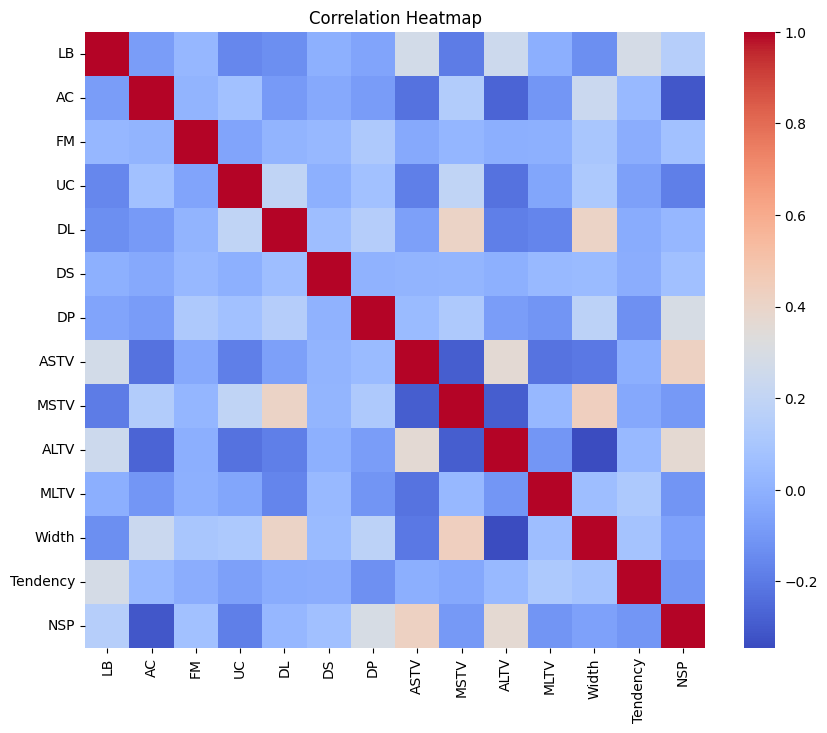

In [14]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [15]:
#Pair Plot

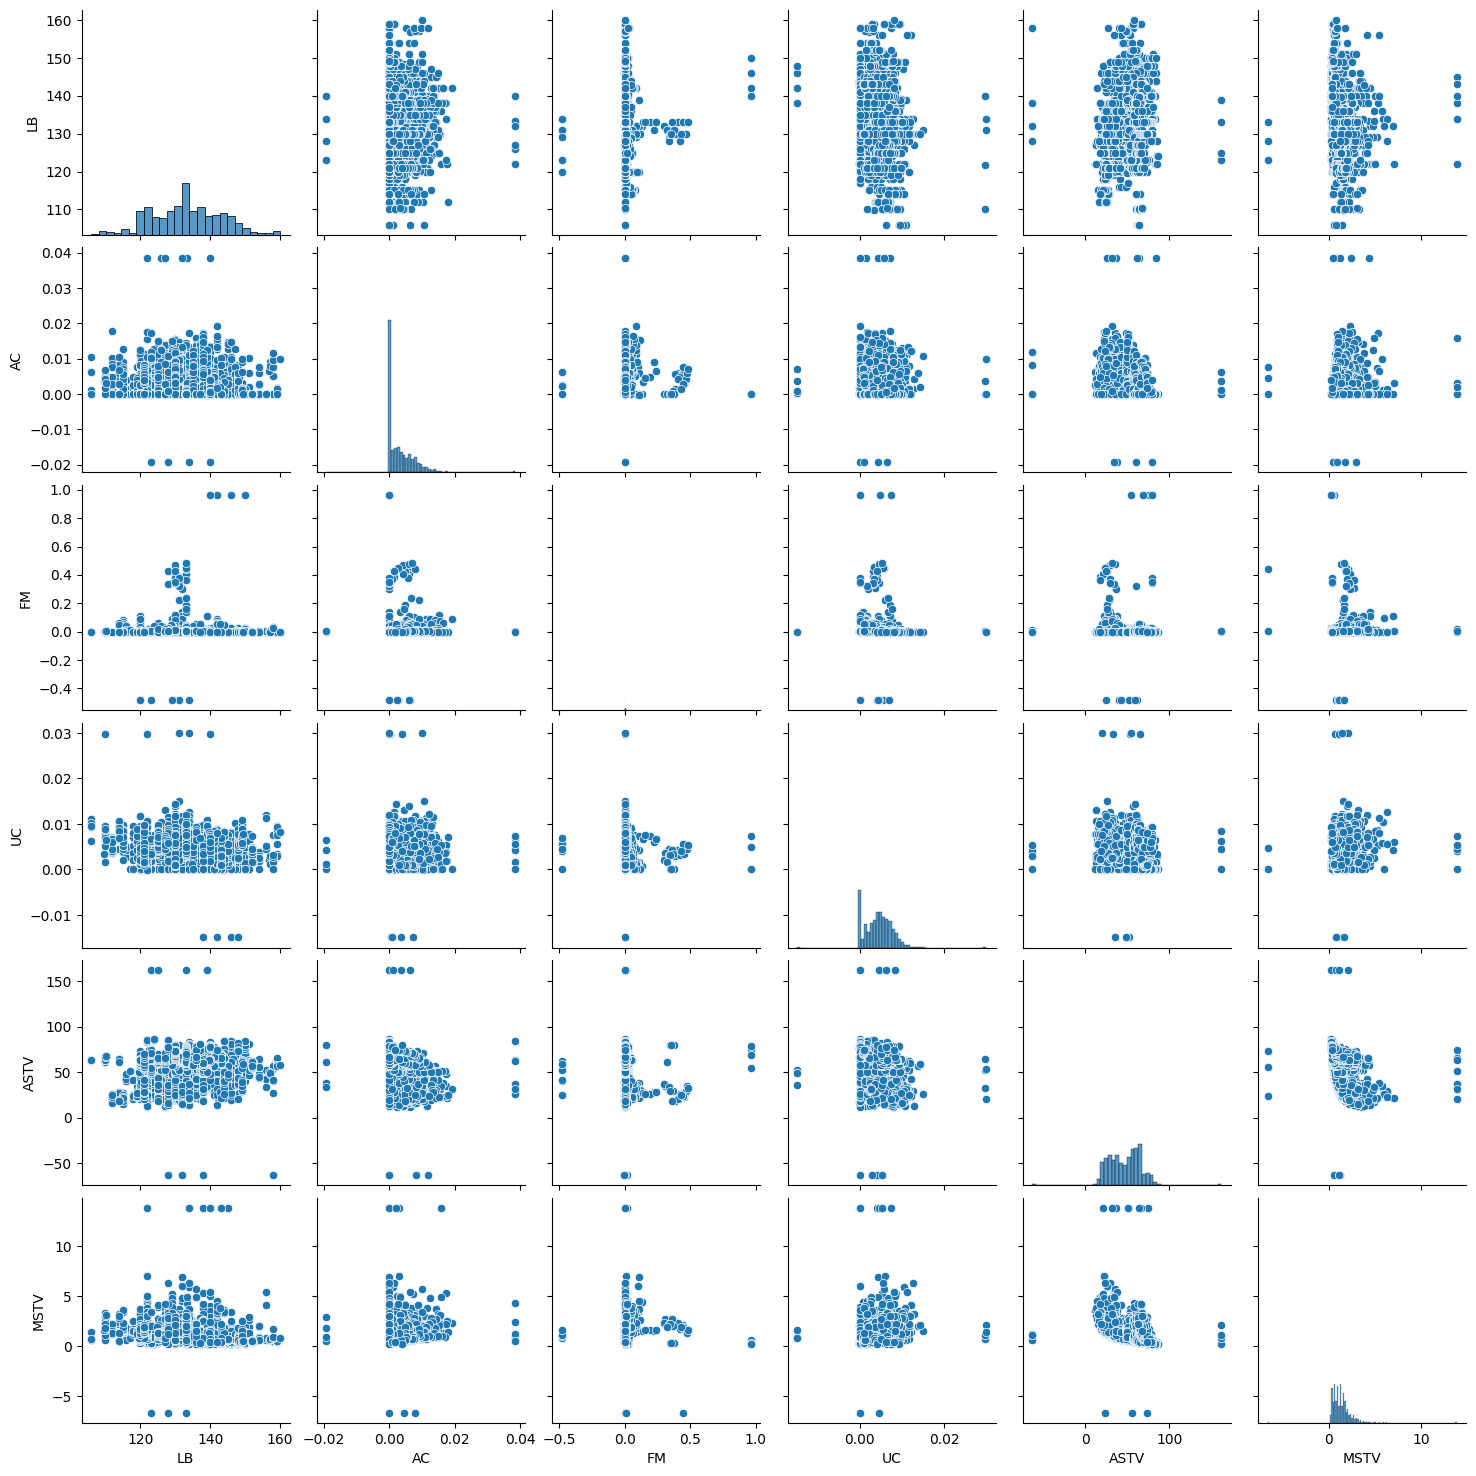

In [16]:
sns.pairplot(df[['LB','AC','FM','UC','ASTV','MSTV']])
plt.show()

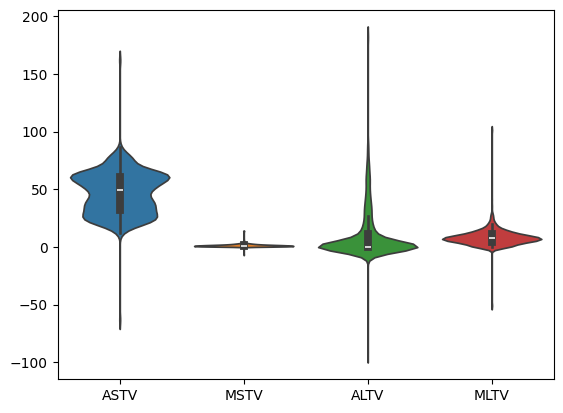

In [17]:
#Violin Plot
sns.violinplot(data=df[['ASTV','MSTV','ALTV','MLTV']])
plt.show()

5. Pattern Recognition & Insights

In [18]:
df.corr()['LB'].sort_values(ascending=False)

,LB
LB,1.000000
Tendency,0.283046
ASTV,0.271344
ALTV,0.244419
NSP,0.149488
FM,0.022684
DS,-0.006097
MLTV,-0.013544
DP,-0.053308
AC,-0.079131


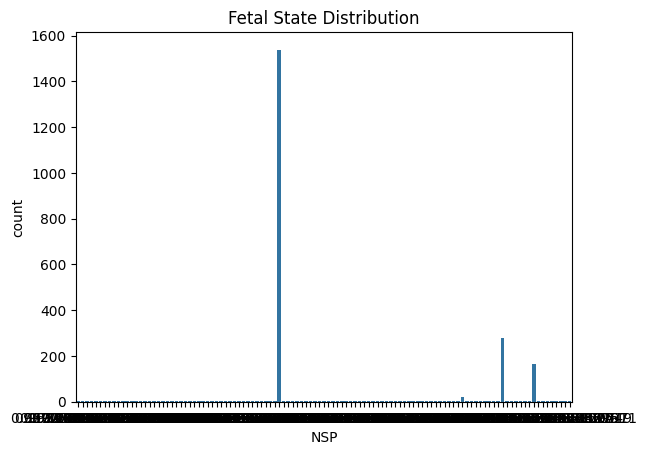

In [19]:
if 'NSP' in df.columns:
    sns.countplot(x='NSP', data=df)
    plt.title("Fetal State Distribution")
    plt.show()

The exploratory analysis of the cardiotocographic dataset revealed important fetal health indicators. Baseline fetal heart rate remained within the normal clinical range for most observations. Accelerations showed positive correlation with fetal well-being, while high abnormal short-term variability (ASTV) indicated potential fetal distress. Uterine contractions were associated with decelerations, suggesting physiological stress patterns. Variability measures such as MSTV and MLTV demonstrated meaningful spread, reflecting differences in fetal heart rate dynamics. Correlation analysis confirmed relationships among accelerations, variability metrics, and decelerations. Overall, the dataset provides strong indicators for fetal health assessment and can support predictive modeling for early detection of fetal distress.

# New Section